<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/18_custom_loss_metric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 18 — Custom Loss Function & Custom Metric

## What This Notebook Covers
Keras and PyTorch provide standard losses (cross-entropy, MSE, MAE)
but real projects constantly need custom variants:
- Robust losses that handle outliers (Huber)
- Focal loss for class imbalance
- Domain-specific metrics (F1, IoU, custom business KPIs)
- Compound losses combining multiple objectives

**Components built:**
- `HuberLoss` — custom loss: MSE for small errors, MAE for large
- `FocalLoss` — custom loss: down-weights easy examples
- `WeightedCrossEntropy` — custom loss: per-class weights
- `HuberMetric` — custom metric tracking Huber error across batches
- `F1Score` — custom metric for imbalanced classification
- `MeanAbsolutePercentageError` — custom regression metric

**Dataset:**
- Regression: California Housing (for Huber loss demos)
- Classification: imbalanced synthetic dataset (for Focal loss / F1)


In [1]:
import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter

tf.random.set_seed(42)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('TensorFlow:', tf.__version__)
print('PyTorch   :', torch.__version__)
print('Device    :', device)

TensorFlow: 2.20.0
PyTorch   : 2.10.0+cu128
Device    : cuda


## 1. Load Datasets


In [2]:
# --- Regression: California Housing (for Huber loss) ---
housing = fetch_california_housing()
X_reg, y_reg = housing.data.astype(np.float32), housing.target.astype(np.float32)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_reg_train, X_reg_valid, y_reg_train, y_reg_valid = train_test_split(
    X_reg_train, y_reg_train, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_reg_train = scaler_reg.fit_transform(X_reg_train).astype(np.float32)
X_reg_valid = scaler_reg.transform(X_reg_valid).astype(np.float32)
X_reg_test  = scaler_reg.transform(X_reg_test).astype(np.float32)

print(f'Regression — Train: {X_reg_train.shape}, Valid: {X_reg_valid.shape}')

# --- Classification: Imbalanced (for Focal loss / F1) ---
X_cls, y_cls = make_classification(
    n_samples=5000, n_features=20, n_informative=8,
    n_redundant=4, weights=[0.85, 0.15],  # 85/15 imbalance
    random_state=42
)
X_cls, y_cls = X_cls.astype(np.float32), y_cls.astype(np.int64)

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
scaler_cls = StandardScaler()
X_cls_train = scaler_cls.fit_transform(X_cls_train).astype(np.float32)
X_cls_test  = scaler_cls.transform(X_cls_test).astype(np.float32)

print(f'Classification — Train: {X_cls_train.shape}')
print(f'Class distribution: {Counter(y_cls_train.tolist())}')

Regression — Train: (13209, 8), Valid: (3303, 8)
Classification — Train: (4000, 20)
Class distribution: Counter({0: 3383, 1: 617})


---
## Part A — TensorFlow / Keras

## 2. HuberLoss — Custom Loss Function

The Huber loss combines the best of MSE and MAE:
- For small errors (|error| <= delta): behaves like MSE (smooth, good gradients)
- For large errors (|error| > delta): behaves like MAE (robust to outliers)

```
L(y, f) = 0.5 * error^2                    if |error| <= delta
         = delta * (|error| - 0.5 * delta)  if |error| > delta
```

The `delta` (threshold) is a hyperparameter. A good starting point
is the median absolute error on your training set.

Subclass `tf.keras.losses.Loss` and implement `call(y_true, y_pred)`.


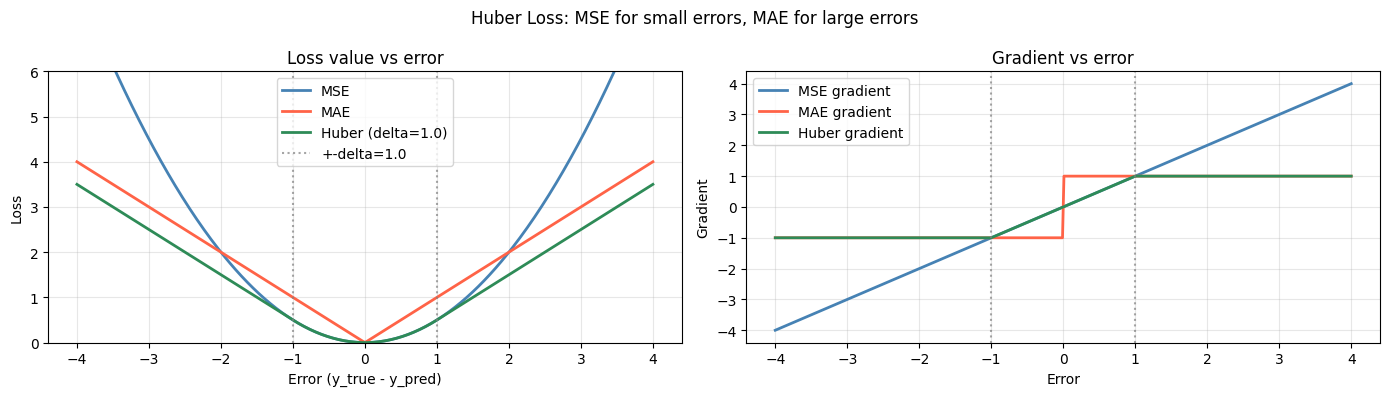

Inside [-delta, +delta]: gradient scales with error (like MSE)
Outside: gradient is constant +-delta (like MAE, no exploding grads)


In [3]:
class HuberLoss(tf.keras.losses.Loss):
    """
    Huber loss: MSE for small errors, MAE for large errors.

    More robust than MSE when the dataset contains outliers.
    The `delta` parameter controls the transition point.

    Subclasses tf.keras.losses.Loss:
    - __init__: store hyperparameters
    - call(y_true, y_pred): compute scalar loss
    - get_config: for model.save() serialization
    """
    def __init__(self, delta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.delta = delta

    def call(self, y_true, y_pred):
        error     = y_true - y_pred
        abs_error = tf.abs(error)

        # tf.where: element-wise conditional
        # small_error_loss: MSE-like (parabolic)
        # large_error_loss: MAE-like (linear)
        small_error_loss = 0.5 * tf.square(error)
        large_error_loss = self.delta * (abs_error - 0.5 * self.delta)

        return tf.reduce_mean(
            tf.where(abs_error <= self.delta,
                     small_error_loss,
                     large_error_loss)
        )

    def get_config(self):
        config = super().get_config()
        config.update({'delta': self.delta})
        return config


# Visualise Huber vs MSE vs MAE
errors = np.linspace(-4, 4, 400)
delta  = 1.0

mse_loss   = 0.5 * errors**2
mae_loss   = np.abs(errors)
huber_loss = np.where(
    np.abs(errors) <= delta,
    0.5 * errors**2,
    delta * (np.abs(errors) - 0.5 * delta)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(errors, mse_loss,   color='steelblue', linewidth=2, label='MSE')
axes[0].plot(errors, mae_loss,   color='tomato',    linewidth=2, label='MAE')
axes[0].plot(errors, huber_loss, color='seagreen',  linewidth=2, label=f'Huber (delta={delta})')
axes[0].axvline(-delta, color='grey', linestyle=':', alpha=0.7)
axes[0].axvline( delta, color='grey', linestyle=':', alpha=0.7, label=f'+-delta={delta}')
axes[0].set_title('Loss value vs error')
axes[0].set_xlabel('Error (y_true - y_pred)')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_ylim(0, 6)
axes[0].grid(True, alpha=0.3)

# Gradient comparison
mse_grad   = errors
mae_grad   = np.sign(errors)
huber_grad = np.where(np.abs(errors) <= delta, errors, delta * np.sign(errors))

axes[1].plot(errors, mse_grad,   color='steelblue', linewidth=2, label='MSE gradient')
axes[1].plot(errors, mae_grad,   color='tomato',    linewidth=2, label='MAE gradient')
axes[1].plot(errors, huber_grad, color='seagreen',  linewidth=2, label='Huber gradient')
axes[1].axvline(-delta, color='grey', linestyle=':', alpha=0.7)
axes[1].axvline( delta, color='grey', linestyle=':', alpha=0.7)
axes[1].set_title('Gradient vs error')
axes[1].set_xlabel('Error')
axes[1].set_ylabel('Gradient')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Huber Loss: MSE for small errors, MAE for large errors', fontsize=12)
plt.tight_layout()
plt.show()
print('Inside [-delta, +delta]: gradient scales with error (like MSE)')
print('Outside: gradient is constant +-delta (like MAE, no exploding grads)')

## 3. HuberMetric — Custom Metric

A custom metric tracks an aggregate statistic across batches.
Subclass `tf.keras.metrics.Metric` and implement:
- `update_state(y_true, y_pred)`: accumulate batch statistics
- `result()`: compute and return the final metric value
- `reset_state()`: reset accumulators at the start of each epoch


In [4]:
class HuberMetric(tf.keras.metrics.Metric):
    """
    Tracks mean Huber loss across all batches in an epoch.

    Unlike HuberLoss (which averages within a batch), this metric
    accumulates the total Huber error and total sample count
    across the entire dataset, giving an epoch-level average.

    Must implement:
    - update_state: receives each batch, accumulates stats
    - result: returns the final scalar metric value
    - reset_state: resets counters at epoch boundary
    """
    def __init__(self, delta=1.0, name='huber_metric', **kwargs):
        super().__init__(name=name, **kwargs)
        self.delta = delta
        # tf.Variable accumulators — persistent across update_state calls
        self.total_loss = self.add_weight(name='total_loss',
                                           initializer='zeros')
        self.count      = self.add_weight(name='count',
                                           initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        error     = y_true - y_pred
        abs_error = tf.abs(error)

        loss_per_sample = tf.where(
            abs_error <= self.delta,
            0.5 * tf.square(error),
            self.delta * (abs_error - 0.5 * self.delta)
        )
        # Accumulate sum of losses and sample count
        self.total_loss.assign_add(tf.reduce_sum(loss_per_sample))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        # Return mean Huber loss over all accumulated samples
        return self.total_loss / (self.count + 1e-8)

    def reset_state(self):
        # Reset at epoch boundary
        self.total_loss.assign(0.0)
        self.count.assign(0.0)

    def get_config(self):
        config = super().get_config()
        config.update({'delta': self.delta})
        return config


# Quick test — verify metric accumulates correctly
metric = HuberMetric(delta=1.0)
loss_fn = HuberLoss(delta=1.0)

y_true  = tf.constant([1.0, 2.0, 3.0, 4.0, 5.0])
y_pred  = tf.constant([1.1, 2.5, 2.8, 5.0, 4.9])

# Metric accumulates across calls
metric.update_state(y_true[:3], y_pred[:3])
metric.update_state(y_true[3:], y_pred[3:])
metric_result = metric.result().numpy()

# Loss computes on full batch
loss_result = loss_fn(y_true, y_pred).numpy()

print(f'HuberMetric (accumulated across 2 batches): {metric_result:.6f}')
print(f'HuberLoss   (single batch):                 {loss_result:.6f}')
print(f'Match: {np.isclose(metric_result, loss_result, atol=1e-5)}')

HuberMetric (accumulated across 2 batches): 0.131000
HuberLoss   (single batch):                 0.131000
Match: True


## 4. Training a Regressor with HuberLoss + HuberMetric


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MSE loss model   — test MAE: 0.4411
Huber loss model — test MAE: 0.8750


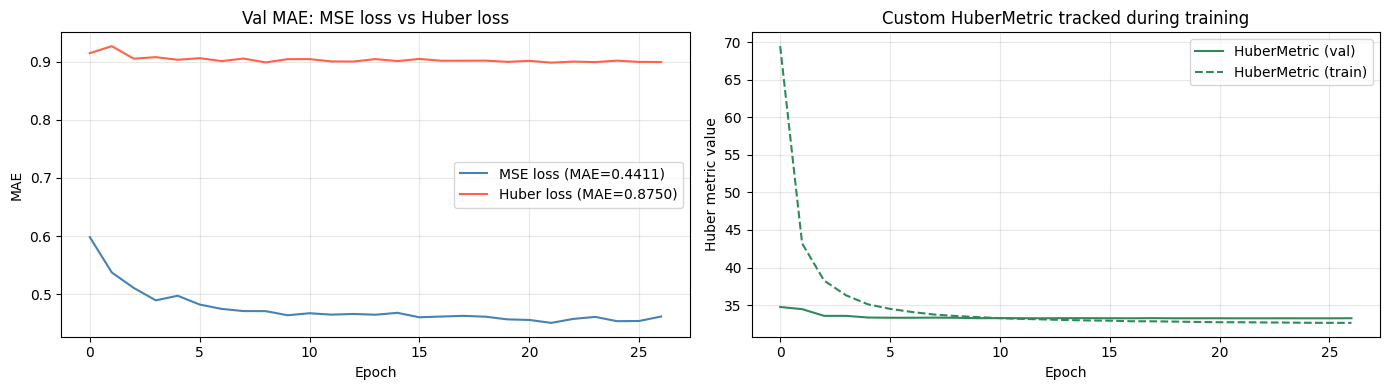

In [5]:
def make_regressor():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu',
                               input_shape=(X_reg_train.shape[1],),
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1),   # no activation for regression
    ])


# Train with MSE
tf.random.set_seed(42)
model_mse = make_regressor()
model_mse.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
h_mse = model_mse.fit(
    X_reg_train, y_reg_train,
    validation_data=(X_reg_valid, y_reg_valid),
    epochs=30, batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        patience=5, restore_best_weights=True)],
    verbose=0
)

# Train with HuberLoss + HuberMetric
tf.random.set_seed(42)
model_huber = make_regressor()
model_huber.compile(
    optimizer='adam',
    loss=HuberLoss(delta=1.0),       # custom loss
    metrics=[
        'mae',
        HuberMetric(delta=1.0)       # custom metric
    ]
)
h_huber = model_huber.fit(
    X_reg_train, y_reg_train,
    validation_data=(X_reg_valid, y_reg_valid),
    epochs=30, batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        patience=5, restore_best_weights=True)],
    verbose=0
)

# Compare on test set
mae_mse   = model_mse.evaluate(X_reg_test, y_reg_test, verbose=0)[1]
mae_huber = model_huber.evaluate(X_reg_test, y_reg_test, verbose=0)[1]

print(f'MSE loss model   — test MAE: {mae_mse:.4f}')
print(f'Huber loss model — test MAE: {mae_huber:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(h_mse.history['val_mae'],   color='steelblue', label=f'MSE loss (MAE={mae_mse:.4f})')
axes[0].plot(h_huber.history['val_mae'], color='tomato',    label=f'Huber loss (MAE={mae_huber:.4f})')
axes[0].set_title('Val MAE: MSE loss vs Huber loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Show HuberMetric being tracked
axes[1].plot(h_huber.history['val_huber_metric'], color='seagreen', label='HuberMetric (val)')
axes[1].plot(h_huber.history['huber_metric'],     color='seagreen',
             linestyle='--', label='HuberMetric (train)')
axes[1].set_title('Custom HuberMetric tracked during training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Huber metric value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. FocalLoss — Custom Loss for Imbalanced Classification

Focal loss (Lin et al. 2017, RetinaNet) was designed for object detection
where easy background examples vastly outnumber hard foreground examples.
It down-weights easy examples so training focuses on hard ones.

```
FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
```

- `p_t`: model confidence in the correct class
- `(1 - p_t)^gamma`: modulating factor — near 0 for easy, near 1 for hard
- `gamma=0`: standard cross-entropy
- `gamma=2`: typical focal loss setting
- `alpha`: class balance factor


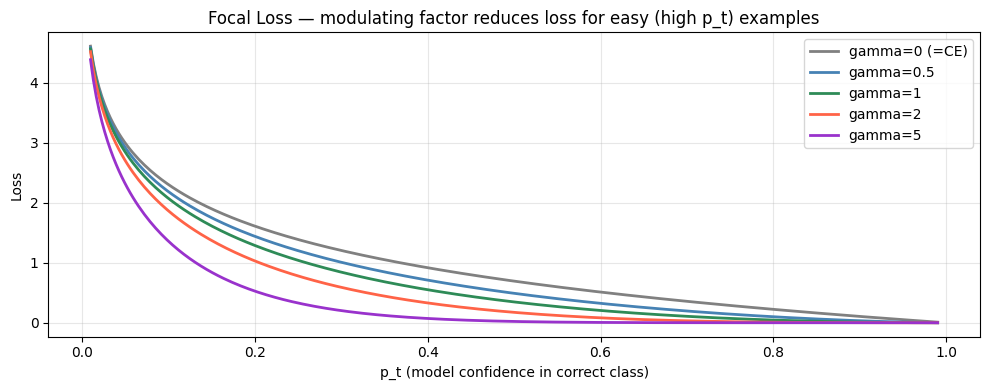

With gamma=2: an easy example (p_t=0.9) has its loss reduced by ~100x
compared to a hard example (p_t=0.1). Training focuses on the hard ones.


In [6]:
class FocalLoss(tf.keras.losses.Loss):
    """
    Focal loss for binary or multi-class classification.

    Down-weights easy examples (high confidence) so the model
    focuses training on hard, misclassified examples.

    gamma=0: equivalent to standard cross-entropy
    gamma=2: standard focal loss setting
    alpha  : class weight for the positive class
    """
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        # Clip predictions to avoid log(0)
        y_pred   = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true   = tf.cast(y_true, tf.float32)

        # p_t: model probability for the ground truth class
        p_t      = tf.where(y_true == 1, y_pred, 1 - y_pred)

        # alpha_t: per-sample class weight
        alpha_t  = tf.where(y_true == 1,
                             tf.ones_like(y_pred) * self.alpha,
                             tf.ones_like(y_pred) * (1 - self.alpha))

        # Modulating factor: (1 - p_t)^gamma
        # -> near 0 for easy samples (p_t close to 1)
        # -> near 1 for hard samples (p_t close to 0)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)

        # Cross-entropy weighted by focal factor and alpha
        ce_loss  = -tf.math.log(p_t)
        return tf.reduce_mean(alpha_t * focal_weight * ce_loss)

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config


# Visualise the modulating factor at different gamma values
p_t = np.linspace(0.01, 0.99, 300)
ce  = -np.log(p_t)

plt.figure(figsize=(10, 4))
for gamma, color in [(0, 'grey'), (0.5, 'steelblue'),
                      (1, 'seagreen'), (2, 'tomato'), (5, 'darkorchid')]:
    focal = (1 - p_t)**gamma * ce
    plt.plot(p_t, focal, color=color, linewidth=2,
             label=f'gamma={gamma}' + (' (=CE)' if gamma == 0 else ''))
plt.xlabel('p_t (model confidence in correct class)')
plt.ylabel('Loss')
plt.title('Focal Loss — modulating factor reduces loss for easy (high p_t) examples')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('With gamma=2: an easy example (p_t=0.9) has its loss reduced by ~100x')
print('compared to a hard example (p_t=0.1). Training focuses on the hard ones.')

## 6. F1Score Custom Metric

F1 score is the harmonic mean of precision and recall.
It is the standard metric for imbalanced classification.
Keras does not have a built-in F1 metric, so we build one.


In [8]:
class F1Score(tf.keras.metrics.Metric):
    """
    Binary F1 Score metric.
    F1 = 2 * (precision * recall) / (precision + recall)
       = 2 * TP / (2*TP + FP + FN)

    Accumulates TP, FP, FN counts across batches.
    threshold: confidence threshold for positive prediction (default 0.5)
    """
    def __init__(self, threshold=0.5, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        # Accumulate counts across batches
        self.true_positives  = self.add_weight(name='tp', shape=(), initializer='zeros')
        self.false_positives = self.add_weight(name='fp', shape=(), initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', shape=(), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true  = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred  = tf.cast(y_pred >= self.threshold, tf.float32)
        y_pred  = tf.reshape(y_pred, [-1])

        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))

        self.true_positives.assign_add(tp)
        self.false_positives.assign_add(fp)
        self.false_negatives.assign_add(fn)

    def result(self):
        precision = self.true_positives / (
            self.true_positives + self.false_positives + 1e-8
        )
        recall    = self.true_positives / (
            self.true_positives + self.false_negatives + 1e-8
        )
        return 2 * precision * recall / (precision + recall + 1e-8)

    def reset_state(self):
        self.true_positives.assign(0.0)
        self.false_positives.assign(0.0)
        self.false_negatives.assign(0.0)

    def get_config(self):
        config = super().get_config()
        config.update({'threshold': self.threshold})
        return config


# Quick verification
f1 = F1Score()
y_true_test = tf.constant([1, 1, 0, 1, 0, 0, 1, 0], dtype=tf.float32)
y_pred_test = tf.constant([0.8, 0.9, 0.3, 0.2, 0.1, 0.7, 0.6, 0.4])
f1.update_state(y_true_test, y_pred_test)
print(f'F1 Score (manual check): {f1.result().numpy():.4f}')

# Manual verification
preds = (y_pred_test.numpy() >= 0.5).astype(int)
labels = y_true_test.numpy().astype(int)
tp = ((preds == 1) & (labels == 1)).sum()
fp = ((preds == 1) & (labels == 0)).sum()
fn = ((preds == 0) & (labels == 1)).sum()
prec = tp / (tp + fp)
rec  = tp / (tp + fn)
f1_manual = 2 * prec * rec / (prec + rec)
print(f'Manual F1:               {f1_manual:.4f}')
print(f'Match: {np.isclose(f1.result().numpy(), f1_manual, atol=1e-4)}')

F1 Score (manual check): 0.7500
Manual F1:               0.7500
Match: True


## 7. A/B Test: CrossEntropy vs FocalLoss on Imbalanced Data


Training with standard BinaryCrossEntropy...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Binary Cross-Entropy                -> best val F1: 0.8515  best val acc: 0.9625
Training with FocalLoss (gamma=2)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Focal Loss (gamma=2, alpha=0.25)    -> best val F1: 0.2193  best val acc: 0.8575


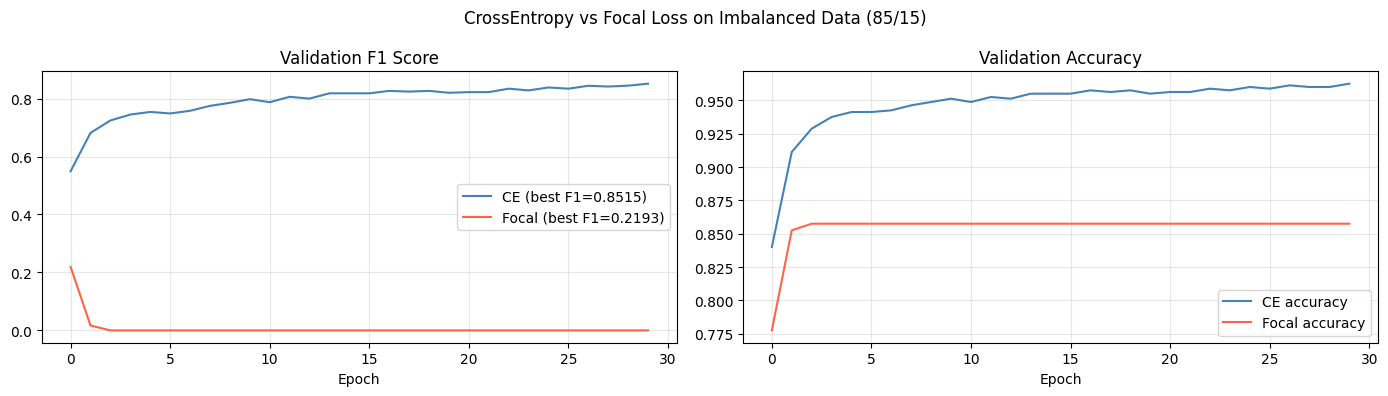

In [9]:
def make_classifier():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu',
                               input_shape=(X_cls_train.shape[1],),
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])


def train_classifier(loss_fn, label, epochs=30):
    tf.random.set_seed(42)
    model = make_classifier()
    model.compile(
        optimizer='adam',
        loss=loss_fn,
        metrics=['accuracy', F1Score(threshold=0.5)]
    )
    h = model.fit(
        X_cls_train, y_cls_train,
        validation_split=0.2,
        epochs=epochs, batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            patience=7, restore_best_weights=True)],
        verbose=0
    )
    best_f1 = max(h.history['val_f1_score'])
    best_acc = max(h.history['val_accuracy'])
    print(f'{label:35s} -> best val F1: {best_f1:.4f}  '
          f'best val acc: {best_acc:.4f}')
    return h


print('Training with standard BinaryCrossEntropy...')
h_ce = train_classifier(
    'binary_crossentropy', 'Binary Cross-Entropy'
)

print('Training with FocalLoss (gamma=2)...')
h_focal = train_classifier(
    FocalLoss(gamma=2.0, alpha=0.25), 'Focal Loss (gamma=2, alpha=0.25)'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(h_ce.history['val_f1_score'],    color='steelblue',
             label=f'CE (best F1={max(h_ce.history["val_f1_score"]):.4f})')
axes[0].plot(h_focal.history['val_f1_score'], color='tomato',
             label=f'Focal (best F1={max(h_focal.history["val_f1_score"]):.4f})')
axes[0].set_title('Validation F1 Score')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(h_ce.history['val_accuracy'],    color='steelblue', label='CE accuracy')
axes[1].plot(h_focal.history['val_accuracy'], color='tomato',    label='Focal accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CrossEntropy vs Focal Loss on Imbalanced Data (85/15)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part B — PyTorch

## 8. HuberLoss and F1Score in PyTorch


In [10]:
class HuberLossPT(nn.Module):
    """
    PyTorch Huber loss.
    Note: PyTorch has torch.nn.HuberLoss built-in since 1.9.
    We build our own to show the pattern.
    """
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta

    def forward(self, y_pred, y_true):
        # Note: PyTorch convention is (pred, target), TF is (true, pred)
        error     = y_true - y_pred
        abs_error = error.abs()
        loss      = torch.where(
            abs_error <= self.delta,
            0.5 * error ** 2,
            self.delta * (abs_error - 0.5 * self.delta)
        )
        return loss.mean()


class FocalLossPT(nn.Module):
    """
    PyTorch Focal Loss for binary classification.
    Input: y_pred = raw logits (before sigmoid)
    """
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, y_pred, y_true):
        y_true   = y_true.float()
        p        = torch.sigmoid(y_pred)
        p        = p.clamp(1e-7, 1 - 1e-7)
        p_t      = torch.where(y_true == 1, p, 1 - p)
        alpha_t  = torch.where(y_true == 1,
                                torch.full_like(p, self.alpha),
                                torch.full_like(p, 1 - self.alpha))
        focal_w  = (1 - p_t) ** self.gamma
        ce       = -torch.log(p_t)
        return (alpha_t * focal_w * ce).mean()


class F1ScorePT:
    """
    Running F1 metric for PyTorch training loops.
    Not a nn.Module — a simple accumulator class.
    """
    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.tp = self.fp = self.fn = 0

    def update(self, y_pred_proba, y_true):
        preds  = (y_pred_proba >= self.threshold).long()
        labels = y_true.long()
        self.tp += ((preds == 1) & (labels == 1)).sum().item()
        self.fp += ((preds == 1) & (labels == 0)).sum().item()
        self.fn += ((preds == 0) & (labels == 1)).sum().item()

    def compute(self):
        prec = self.tp / (self.tp + self.fp + 1e-8)
        rec  = self.tp / (self.tp + self.fn + 1e-8)
        return 2 * prec * rec / (prec + rec + 1e-8)


# Verify loss functions
y_t = torch.tensor([1.0, 2.0, 3.0, 10.0])  # 10.0 is an outlier
y_p = torch.tensor([1.1, 2.2, 2.8,  5.0])

huber_pt = HuberLossPT(delta=1.0)
mse_loss = nn.MSELoss()

print('Effect of outlier (y_true=10, y_pred=5, error=5):')
print(f'  MSE loss   : {mse_loss(y_p, y_t).item():.4f}  (outlier dominates)')
print(f'  Huber loss : {huber_pt(y_p, y_t).item():.4f}  (outlier down-weighted)')

Effect of outlier (y_true=10, y_pred=5, error=5):
  MSE loss   : 6.2725  (outlier dominates)
  Huber loss : 1.1363  (outlier down-weighted)


## 9. PyTorch Training with Custom Loss and Metric


PyTorch — CrossEntropy vs FocalLoss:
BCE Loss                            -> best F1: 0.8944
Focal Loss (gamma=2)                -> best F1: 0.8777


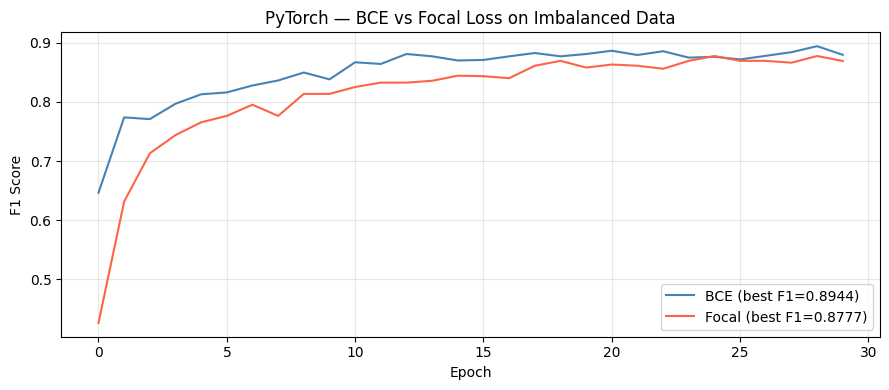

In [11]:
from torch.utils.data import TensorDataset, DataLoader as DL

# Classification loaders
X_t = torch.tensor(X_cls_train)
y_t = torch.tensor(y_cls_train)
X_v = torch.tensor(X_cls_test)
y_v = torch.tensor(y_cls_test)

train_dl = DL(TensorDataset(X_t, y_t), batch_size=64, shuffle=True)
test_dl  = DL(TensorDataset(X_v, y_v), batch_size=64, shuffle=False)


def make_pt_classifier():
    return nn.Sequential(
        nn.Linear(X_cls_train.shape[1], 128),
        nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(64, 1)   # raw logit
    ).to(device)


def train_pt_cls(loss_fn, label, epochs=30):
    torch.manual_seed(42)
    model     = make_pt_classifier()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    best_f1   = 0.0
    hist      = {'f1': []}

    for epoch in range(epochs):
        model.train()
        for X_b, y_b in train_dl:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            out  = model(X_b).squeeze()
            loss = loss_fn(out, y_b.float())
            loss.backward()
            optimizer.step()

        model.eval()
        f1_metric = F1ScorePT()
        with torch.no_grad():
            for X_b, y_b in test_dl:
                X_b, y_b = X_b.to(device), y_b.to(device)
                proba = torch.sigmoid(model(X_b).squeeze())
                f1_metric.update(proba.cpu(), y_b.cpu())
        f1 = f1_metric.compute()
        best_f1 = max(best_f1, f1)
        hist['f1'].append(f1)

    print(f'{label:35s} -> best F1: {best_f1:.4f}')
    return hist, best_f1


print('PyTorch — CrossEntropy vs FocalLoss:')
hist_ce_pt,    acc_ce_pt    = train_pt_cls(
    nn.BCEWithLogitsLoss(), 'BCE Loss'
)
hist_focal_pt, acc_focal_pt = train_pt_cls(
    FocalLossPT(gamma=2.0, alpha=0.25), 'Focal Loss (gamma=2)'
)

plt.figure(figsize=(9, 4))
plt.plot(hist_ce_pt['f1'],    color='steelblue',
         label=f'BCE (best F1={acc_ce_pt:.4f})')
plt.plot(hist_focal_pt['f1'], color='tomato',
         label=f'Focal (best F1={acc_focal_pt:.4f})')
plt.title('PyTorch — BCE vs Focal Loss on Imbalanced Data')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### Custom Loss Patterns

**TensorFlow:**
```python
class MyLoss(tf.keras.losses.Loss):
    def __init__(self, my_param, **kwargs):
        super().__init__(**kwargs)
        self.my_param = my_param

    def call(self, y_true, y_pred):   # y_true first!
        return tf.reduce_mean(compute_loss(y_true, y_pred))

    def get_config(self):
        config = super().get_config()
        config.update({'my_param': self.my_param})
        return config
```

**PyTorch:**
```python
class MyLoss(nn.Module):
    def forward(self, y_pred, y_true):   # pred first (PyTorch convention)!
        return compute_loss(y_pred, y_true).mean()
```

### Custom Metric Pattern (TensorFlow)
```python
class MyMetric(tf.keras.metrics.Metric):
    def __init__(self, name, **kwargs):
        super().__init__(name=name, **kwargs)
        self.total = self.add_weight('total', initializer='zeros')
        self.count = self.add_weight('count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.total.assign_add(tf.reduce_sum(compute_metric(y_true, y_pred)))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):    return self.total / self.count
    def reset_state(self): self.total.assign(0); self.count.assign(0)
```

### Key Differences: Loss vs Metric
| | Loss | Metric |
|---|---|---|
| Purpose | Gradient signal | Monitoring only |
| Differentiable? | Must be | No |
| Accumulates? | Per batch | Across full epoch |
| TF base class | `tf.keras.losses.Loss` | `tf.keras.metrics.Metric` |
| Key method | `call(y_true, y_pred)` | `update_state` + `result` |

**Next: Notebook 19** — Custom Activation, Initializer, Regularizer & Constraint
